In [6]:
import numpy as np 

ts_task= np.load('data/timeseries_task100.npy')

# shape of the data set

In [7]:
ts_task.shape

(100, 2, 360, 176)

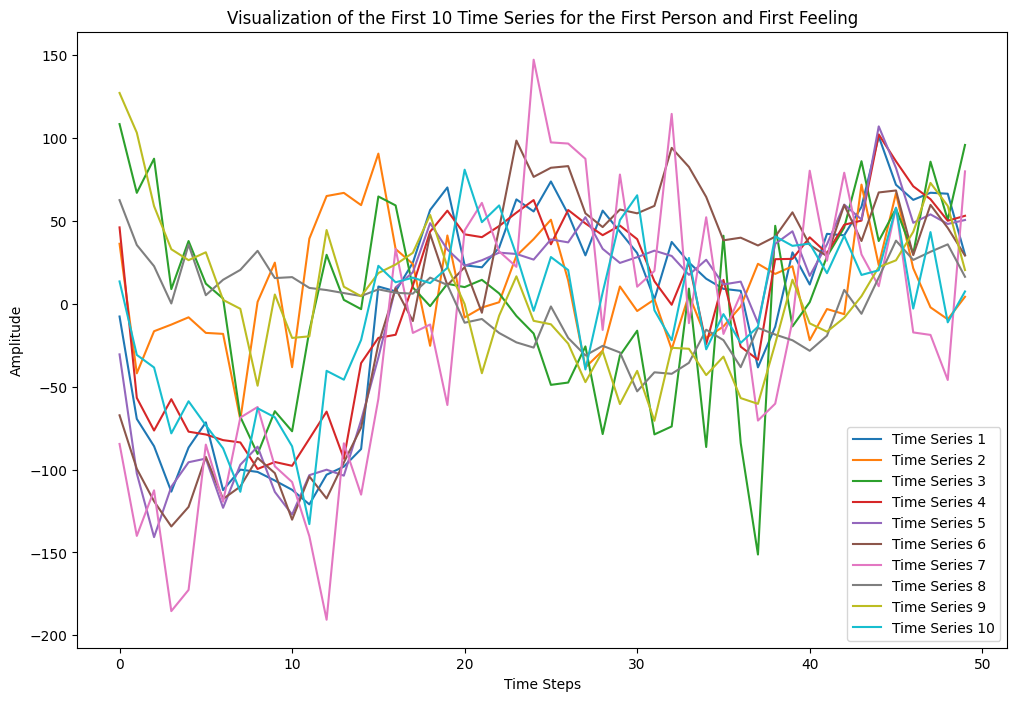

(100, 2, 360, 176)

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
ts_task = np.load('data/timeseries_task100.npy')

# Display the shape of the dataset
dataset_shape = ts_task.shape

# Visualize the first person, first feeling, and first 10 time series for the first 50 time steps
person_idx = 0
feeling_idx = 0
time_series_indices = range(10)
time_steps = range(50)

plt.figure(figsize=(12, 8))
for i, ts_idx in enumerate(time_series_indices):
    plt.plot(time_steps, ts_task[person_idx, feeling_idx, ts_idx, time_steps], label=f'Time Series {ts_idx + 1}')
    
plt.title('Visualization of the First 10 Time Series for the First Person and First Feeling')
plt.xlabel('Time Steps')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

dataset_shape


# so it is 4 D

In [9]:
ts_task[0][0][0].shape

(176,)

Shape of the data: (176,)


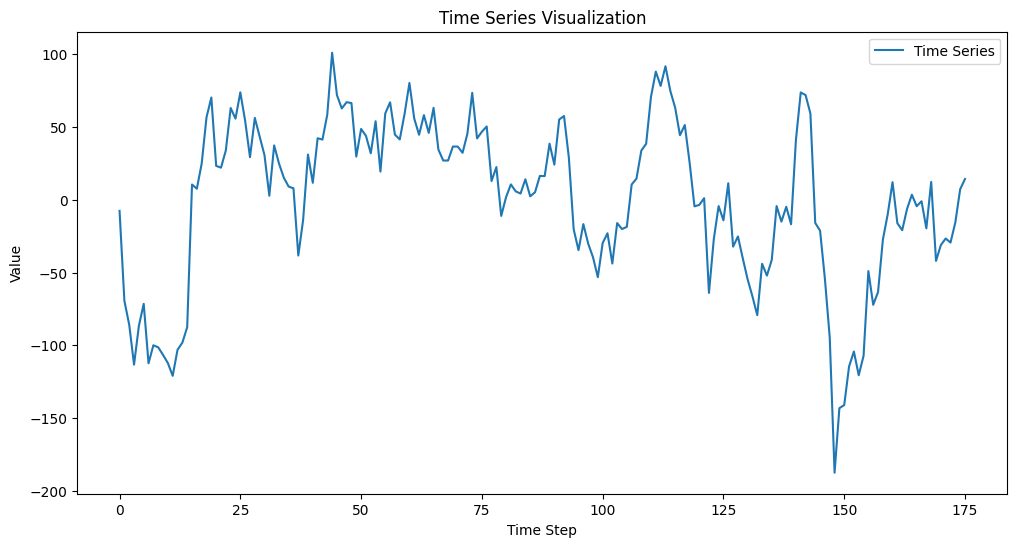

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming ts_task[0][0][0] is your numpy array
time_series = ts_task[0][0][0]

# Check the shape of the data
print("Shape of the data:", time_series.shape)

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(time_series, label='Time Series')

plt.xlabel('Time Step')
plt.ylabel('Value')
plt.title('Time Series Visualization')
plt.legend()
plt.show()

# we need to model the whole 2D time series for 



Shape of the data: (360, 176)


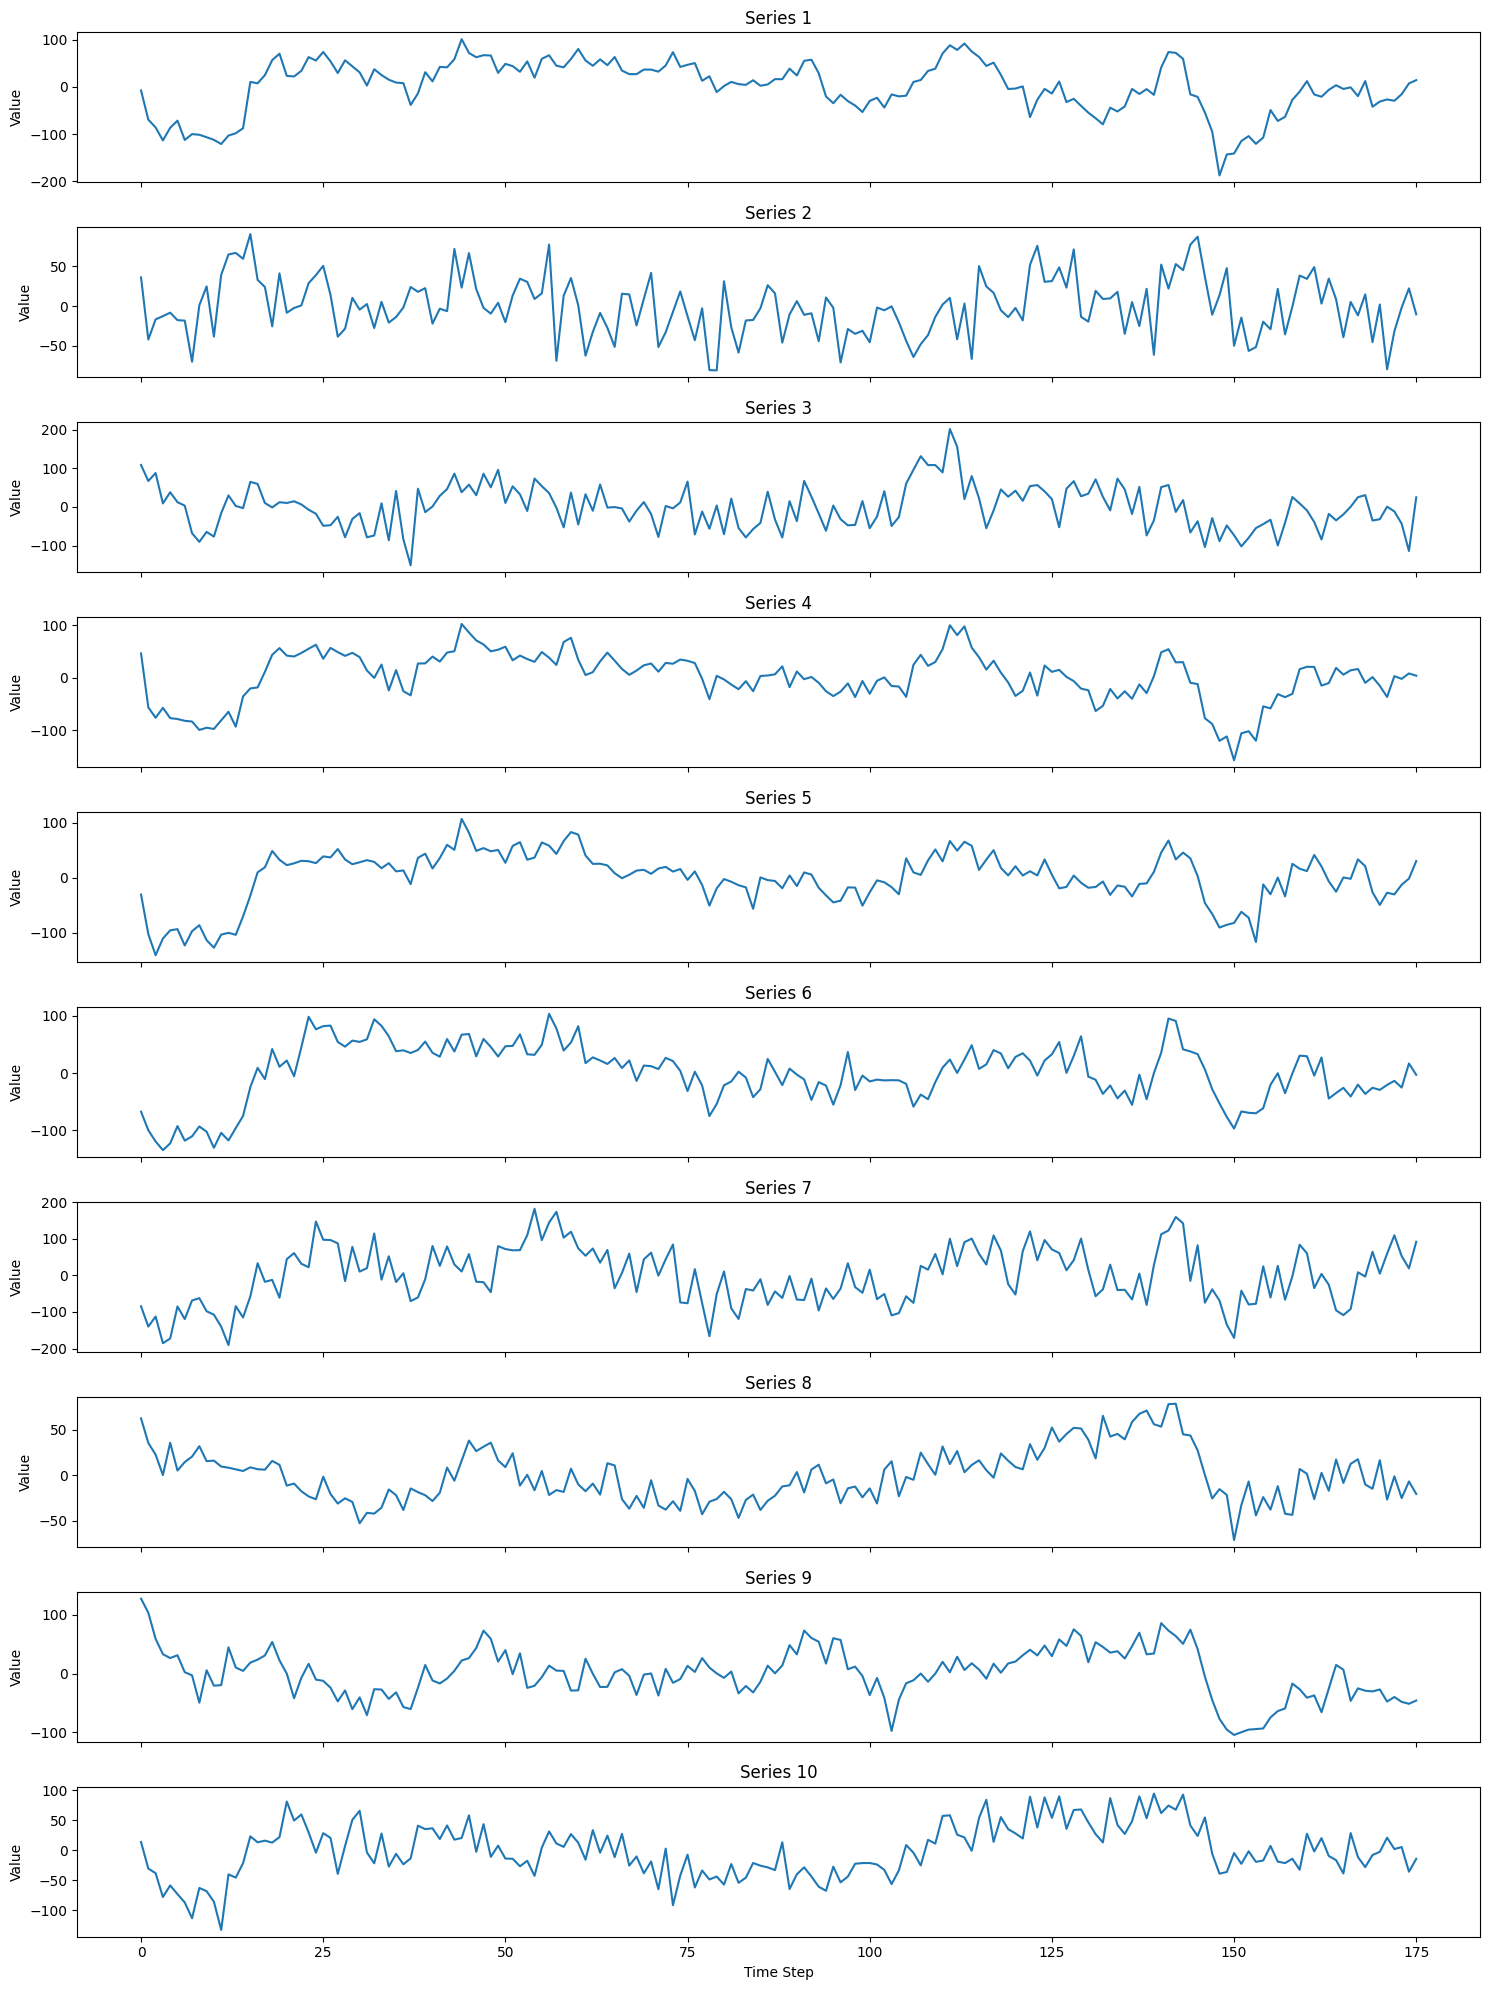

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming ts_task[0][0][0] is your numpy array
time_series = ts_task[0][0]

# Check the shape of the data
print("Shape of the data:", time_series.shape)

def plot_time_series_subset(time_series, start_row, end_row):
    subset = time_series[start_row:end_row]
    num_plots = subset.shape[0]

    fig, axes = plt.subplots(num_plots, 1, figsize=(15, num_plots * 2), sharex=True)

    for i in range(num_plots):
        axes[i].plot(subset[i, :])
        axes[i].set_title(f'Series {start_row + i + 1}')
        axes[i].set_ylabel('Value')

    axes[-1].set_xlabel('Time Step')
    plt.tight_layout()
    plt.show()

# Plot a subset of rows, for example, the first 10 rows
plot_time_series_subset(time_series, 0, 10)


# R&D

In [12]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Assuming ts_task is your numpy array with shape (100, 2, 360, 176)
ts_task = np.random.rand(100, 2, 360, 176)  # Replace with actual data loading

# Reshape data for RNN input: (samples, time steps, features)
# We will combine the 100 persons and 2 feelings into the samples dimension: 100*2 = 200 samples
samples = ts_task.shape[0] * ts_task.shape[1]
time_steps = ts_task.shape[3]
features = ts_task.shape[2]

data = ts_task.reshape((samples, time_steps, features))

# Generate some labels for the example (binary classification)
labels = np.random.randint(2, size=samples)  # Replace with actual labels

# Convert labels to categorical
labels = to_categorical(labels)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)


# RNN

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

# Build RNN model
model = Sequential()
model.add(SimpleRNN(128, input_shape=(time_steps, features), return_sequences=True))
model.add(Dropout(0.2))
model.add(SimpleRNN(128))
model.add(Dropout(0.2))
model.add(Dense(2, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)


Epoch 1/20
4/4 [==============================] - 2s 153ms/step - loss: 1.0357 - accuracy: 0.5078 - val_loss: 0.8681 - val_accuracy: 0.5625
Epoch 2/20
4/4 [==============================] - 0s 73ms/step - loss: 0.8296 - accuracy: 0.5234 - val_loss: 0.7896 - val_accuracy: 0.4375
Epoch 3/20
4/4 [==============================] - 0s 79ms/step - loss: 0.6739 - accuracy: 0.6172 - val_loss: 0.8041 - val_accuracy: 0.5312
Epoch 4/20
4/4 [==============================] - 0s 82ms/step - loss: 0.7523 - accuracy: 0.6016 - val_loss: 0.8073 - val_accuracy: 0.3750
Epoch 5/20
4/4 [==============================] - 0s 85ms/step - loss: 0.5464 - accuracy: 0.7188 - val_loss: 0.7438 - val_accuracy: 0.4062
Epoch 6/20
4/4 [==============================] - 0s 78ms/step - loss: 0.5543 - accuracy: 0.7500 - val_loss: 0.7451 - val_accuracy: 0.5625
Epoch 7/20
4/4 [==============================] - 0s 72ms/step - loss: 0.4496 - accuracy: 0.7891 - val_loss: 0.7972 - val_accuracy: 0.4688
Epoch 8/20
4/4 [==========

2/2 - 0s - loss: 1.8393 - accuracy: 0.5250 - 280ms/epoch - 140ms/step
Test accuracy: 0.5249999761581421


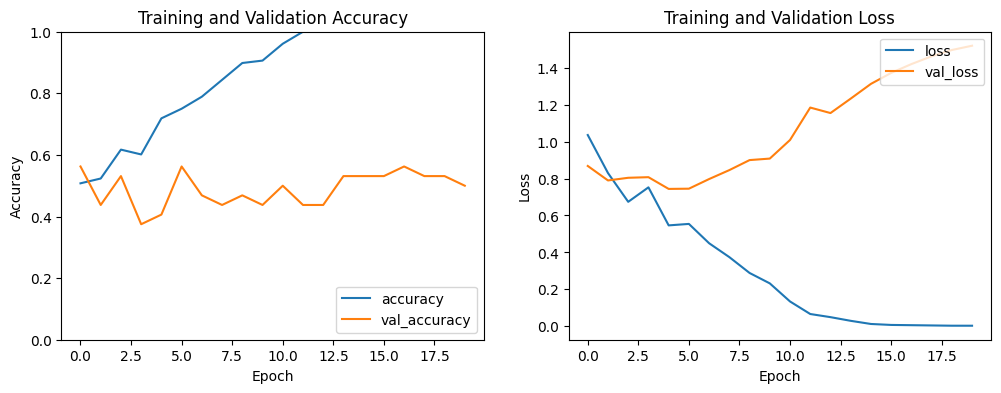

In [14]:
# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'Test accuracy: {test_acc}')

# Plot training & validation accuracy and loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()


# CNN

In [15]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

# Build CNN model
model = Sequential()
model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(time_steps, features)))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(128, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)


Epoch 1/20
4/4 [==============================] - 1s 70ms/step - loss: 1.0273 - accuracy: 0.5078 - val_loss: 0.8986 - val_accuracy: 0.4375
Epoch 2/20
4/4 [==============================] - 0s 30ms/step - loss: 0.8128 - accuracy: 0.4453 - val_loss: 0.7477 - val_accuracy: 0.4375
Epoch 3/20
4/4 [==============================] - 0s 27ms/step - loss: 0.7535 - accuracy: 0.4688 - val_loss: 0.7040 - val_accuracy: 0.5625
Epoch 4/20
4/4 [==============================] - 0s 31ms/step - loss: 0.7271 - accuracy: 0.5391 - val_loss: 0.6889 - val_accuracy: 0.5312
Epoch 5/20
4/4 [==============================] - 0s 26ms/step - loss: 0.6869 - accuracy: 0.5312 - val_loss: 0.6843 - val_accuracy: 0.5625
Epoch 6/20
4/4 [==============================] - 0s 25ms/step - loss: 0.6932 - accuracy: 0.5156 - val_loss: 0.6920 - val_accuracy: 0.5312
Epoch 7/20
4/4 [==============================] - 0s 26ms/step - loss: 0.6803 - accuracy: 0.5703 - val_loss: 0.6838 - val_accuracy: 0.5938
Epoch 8/20
4/4 [===========

2/2 - 0s - loss: 0.6777 - accuracy: 0.5750 - 141ms/epoch - 71ms/step
Test accuracy: 0.574999988079071


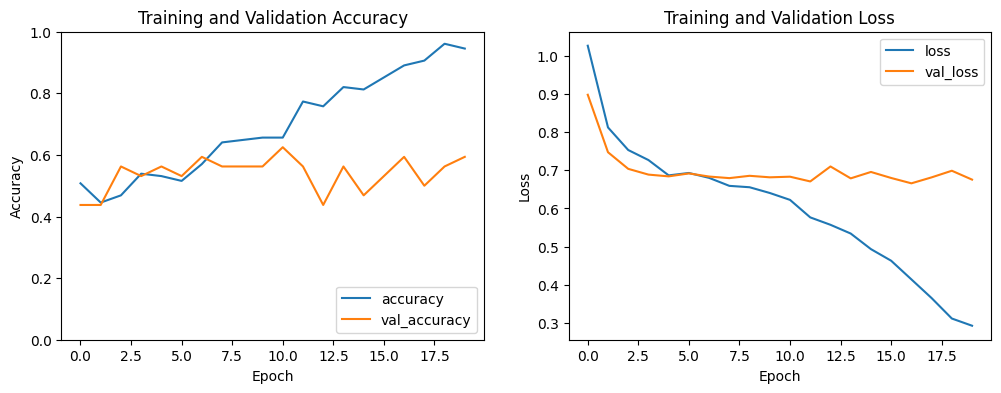

In [16]:
# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'Test accuracy: {test_acc}')

# Plot training & validation accuracy and loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

# adding th HCP data

In [17]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
import matplotlib.pyplot as plt

# Load the data from the .npy file
file_path = 'timeseries_task100.npy' 
ts_task = np.load(file_path)

# Check the shape of the data
print("Shape of the data:", ts_task.shape)

# Reshape data for RNN input: (samples, time steps, features)
# We will combine the 100 persons and 2 feelings into the samples dimension: 100*2 = 200 samples
samples = ts_task.shape[0] * ts_task.shape[1]
time_steps = ts_task.shape[3]
features = ts_task.shape[2]

data = ts_task.reshape((samples, time_steps, features))

# Generate some labels for the example (binary classification)
labels = np.random.randint(2, size=samples)  # Replace with actual labels

# Convert labels to categorical
labels = to_categorical(labels)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Build RNN model
model_rnn = Sequential()
model_rnn.add(SimpleRNN(128, input_shape=(time_steps, features), return_sequences=True))
model_rnn.add(Dropout(0.2))
model_rnn.add(SimpleRNN(128))
model_rnn.add(Dropout(0.2))
model_rnn.add(Dense(2, activation='softmax'))

# Compile the model
model_rnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the RNN model
history_rnn = model_rnn.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Evaluate the RNN model
test_loss_rnn, test_acc_rnn = model_rnn.evaluate(X_test, y_test, verbose=2)
print(f'Test accuracy (RNN): {test_acc_rnn}')

# Plot training & validation accuracy and loss for RNN
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['accuracy'], label='accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (RNN)')

plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['loss'], label='loss')
plt.plot(history_rnn.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (RNN)')

plt.show()

# Build CNN model
model_cnn = Sequential()
model_cnn.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(time_steps, features)))
model_cnn.add(MaxPooling1D(pool_size=2))
model_cnn.add(Conv1D(128, kernel_size=3, activation='relu'))
model_cnn.add(MaxPooling1D(pool_size=2))
model_cnn.add(Flatten())
model_cnn.add(Dense(128, activation='relu'))
model_cnn.add(Dropout(0.5))
model_cnn.add(Dense(2, activation='softmax'))

# Compile the CNN model
model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the CNN model
history_cnn = model_cnn.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

# Evaluate the CNN model
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(X_test, y_test, verbose=2)
print(f'Test accuracy (CNN): {test_acc_cnn}')

# Plot training & validation accuracy and loss for CNN
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (CNN)')

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='loss')
plt.plot(history_cnn.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (CNN)')

plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'timeseries_task100.npy'

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict labels for the test set
y_pred = model_lstm.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

NameError: name 'model_lstm' is not defined

In [ ]:
# Check the shape of the data
print("Shape of the data:", ts_task.shape)

# Reshape data for RNN input: (samples, time steps, features)
# We will combine the 100 persons and 2 feelings into the samples dimension: 100*2 = 200 samples
samples = ts_task.shape[0] * ts_task.shape[1]
time_steps = ts_task.shape[3]
features = ts_task.shape[2]

data = ts_task.reshape((samples, time_steps, features))

# Generate some labels for the example (binary classification)
labels = np.random.randint(2, size=samples)  # Replace with actual labels

# Convert labels to categorical
labels = to_categorical(labels)

# Split into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Build LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(128, input_shape=(time_steps, features), return_sequences=True))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(128))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(2, activation='softmax'))

# Compile the model
model_lstm.compile(optimizer='RMSprop', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the LSTM model
history_lstm = model_lstm.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Evaluate the LSTM model
test_loss_lstm, test_acc_lstm = model_lstm.evaluate(X_test, y_test, verbose=2)
print(f'Test accuracy (LSTM): {test_acc_lstm}')

# Plot training & validation accuracy and loss for LSTM
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['accuracy'], label='accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (LSTM)')

plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['loss'], label='loss')
plt.plot(history_lstm.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (LSTM)')

plt.show()


Shape of the data: (100, 2, 360, 176)


NameError: name 'LSTM' is not defined

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict labels for the test set
y_pred = model_lstm.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

NameError: name 'model_lstm' is not defined

# SVM Model


Test accuracy (SVM): 0.575


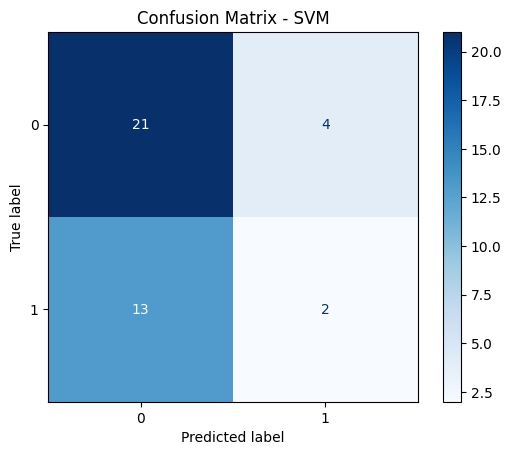

In [26]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Flatten the data
X_train_flat = X_train.reshape((X_train.shape[0], -1))
X_test_flat = X_test.reshape((X_test.shape[0], -1))

# Standardize the data
scaler = StandardScaler()
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)

# Build and train the SVM model
svm = SVC(kernel='linear')
svm.fit(X_train_flat, np.argmax(y_train, axis=1))

# Evaluate the SVM model
test_acc_svm = svm.score(X_test_flat, np.argmax(y_test, axis=1))
print(f'Test accuracy (SVM): {test_acc_svm}')

# Predict and plot confusion matrix
y_pred_svm = svm.predict(X_test_flat)
cm_svm = confusion_matrix(np.argmax(y_test, axis=1), y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - SVM')
plt.show()


# GRU Model


In [27]:
from tensorflow.keras.layers import GRU

# Build GRU model
model_gru = Sequential()
model_gru.add(GRU(128, input_shape=(time_steps, features), return_sequences=True))
model_gru.add(Dropout(0.2))
model_gru.add(GRU(128))
model_gru.add(Dropout(0.2))
model_gru.add(Dense(2, activation='softmax'))

# Compile the model
model_gru.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the GRU model
history_gru = model_gru.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Evaluate the GRU model
test_loss_gru, test_acc_gru = model_gru.evaluate(X_test, y_test, verbose=2)
print(f'Test accuracy (GRU): {test_acc_gru}')

# Predict and plot confusion matrix
y_pred_gru = model_gru.predict(X_test)
y_pred_classes_gru = np.argmax(y_pred_gru, axis=1)
y_true = np.argmax(y_test, axis=1)

cm_gru = confusion_matrix(y_true, y_pred_classes_gru)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gru, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - GRU')
plt.show()


TypeError: Dimension value must be integer or None or have an __index__ method, got value 'range(0, 50)' with type '<class 'range'>'

# Fully Connected (Dense) Neural Network


In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

# Build Fully Connected model
model_dense = Sequential()
model_dense.add(Flatten(input_shape=(time_steps, features)))
model_dense.add(Dense(512, activation='relu'))
model_dense.add(Dropout(0.5))
model_dense.add(Dense(256, activation='relu'))
model_dense.add(Dropout(0.5))
model_dense.add(Dense(2, activation='softmax'))

# Compile the model
model_dense.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the Fully Connected model
history_dense = model_dense.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Evaluate the Fully Connected model
test_loss_dense, test_acc_dense = model_dense.evaluate(X_test, y_test, verbose=2)
print(f'Test accuracy (Fully Connected): {test_acc_dense}')

# Predict and plot confusion matrix
y_pred_dense = model_dense.predict(X_test)
y_pred_classes_dense = np.argmax(y_pred_dense, axis=1)
y_true = np.argmax(y_test, axis=1)

cm_dense = confusion_matrix(y_true, y_pred_classes_dense)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dense, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Fully Connected')
plt.show()

TypeError: Dimension value must be integer or None or have an __index__ method, got value 'range(0, 50)' with type '<class 'range'>'

# 1. Recurrent Neural Networks (RNNs)


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, TimeDistributed

model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(176, 360)))
model.add(LSTM(32, return_sequences=False))
model.add(Dense(2, activation='softmax'))  # Assuming a classification task

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_1 (LSTM)               (None, 176, 64)           108800    
                                                                 
 lstm_2 (LSTM)               (None, 32)                12416     
                                                                 
 dense_7 (Dense)             (None, 2)                 66        
                                                                 
Total params: 121282 (473.76 KB)
Trainable params: 121282 (473.76 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


# 2. Convolutional Neural Networks (CNNs)


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

model = Sequential()
model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(176, 360)))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(32, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dense(2, activation='softmax'))  # Assuming a classification task

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_6 (Conv1D)           (None, 174, 64)           69184     
                                                                 
 max_pooling1d_6 (MaxPoolin  (None, 87, 64)            0         
 g1D)                                                            
                                                                 
 conv1d_7 (Conv1D)           (None, 85, 32)            6176      
                                                                 
 max_pooling1d_7 (MaxPoolin  (None, 42, 32)            0         
 g1D)                                                            
                                                                 
 flatten_3 (Flatten)         (None, 1344)              0         
                                                                 
 dense_8 (Dense)             (None, 100)              

# 3. Combination of CNN and RNN


In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Flatten, Dense

model = Sequential()
model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(176, 360)))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(32, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(100, activation='relu'))
model.add(Dense(2, activation='softmax'))  # Assuming a classification task

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_8 (Conv1D)           (None, 174, 64)           69184     
                                                                 
 max_pooling1d_8 (MaxPoolin  (None, 87, 64)            0         
 g1D)                                                            
                                                                 
 conv1d_9 (Conv1D)           (None, 85, 32)            6176      
                                                                 
 max_pooling1d_9 (MaxPoolin  (None, 42, 32)            0         
 g1D)                                                            
                                                                 
 lstm_3 (LSTM)               (None, 64)                24832     
                                                                 
 dense_10 (Dense)            (None, 100)              

# 5. Training and Evaluation


In [31]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

history = model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=32, 
                    callbacks=[early_stopping, model_checkpoint, reduce_lr])


Epoch 1/100
4/4 [==============================] - 3s 231ms/step - loss: 0.7057 - accuracy: 0.5234 - val_loss: 0.7007 - val_accuracy: 0.4375 - lr: 0.0010
Epoch 2/100
3/4 [=====================>........] - ETA: 0s - loss: 0.6941 - accuracy: 0.5104

c:\Users\ahmad\anaconda3\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


4/4 [==============================] - 0s 56ms/step - loss: 0.6999 - accuracy: 0.4766 - val_loss: 0.6995 - val_accuracy: 0.4375 - lr: 0.0010
Epoch 3/100
4/4 [==============================] - 0s 50ms/step - loss: 0.6935 - accuracy: 0.5078 - val_loss: 0.6876 - val_accuracy: 0.5625 - lr: 0.0010
Epoch 4/100
4/4 [==============================] - 0s 49ms/step - loss: 0.6955 - accuracy: 0.5234 - val_loss: 0.6862 - val_accuracy: 0.5625 - lr: 0.0010
Epoch 5/100
4/4 [==============================] - 0s 37ms/step - loss: 0.6965 - accuracy: 0.5234 - val_loss: 0.6912 - val_accuracy: 0.5625 - lr: 0.0010
Epoch 6/100
4/4 [==============================] - 0s 36ms/step - loss: 0.6934 - accuracy: 0.5234 - val_loss: 0.6882 - val_accuracy: 0.5625 - lr: 0.0010
Epoch 7/100
4/4 [==============================] - 0s 36ms/step - loss: 0.6904 - accuracy: 0.5234 - val_loss: 0.6918 - val_accuracy: 0.5625 - lr: 0.0010
Epoch 8/100
4/4 [==============================] - 0s 39ms/step - loss: 0.6901 - accuracy: 0.5

# 6. Evaluation Metrics


In [32]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes))
print(confusion_matrix(y_true, y_pred_classes))


2/2 [==============================] - 0s 6ms/step
              precision    recall  f1-score   support

           0       0.62      1.00      0.77        25
           1       0.00      0.00      0.00        15

    accuracy                           0.62        40
   macro avg       0.31      0.50      0.38        40
weighted avg       0.39      0.62      0.48        40

[[25  0]
 [15  0]]


c:\Users\ahmad\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ahmad\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ahmad\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Heatmap Visualization


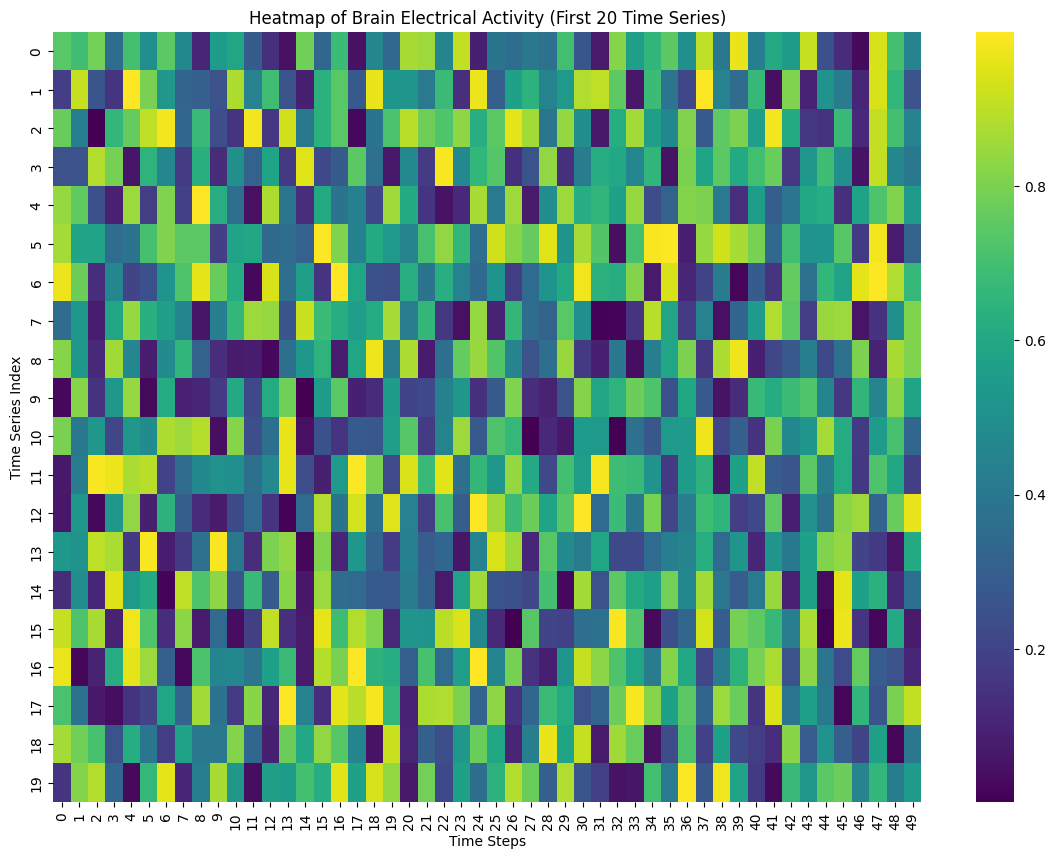

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming ts_task is your dataset loaded as a numpy array
# For demonstration, we'll create a random dataset
ts_task = np.random.rand(100, 2, 360, 176)

# Select the first person, first feeling, and first 20 time series for the first 50 time steps
person_idx = 0
feeling_idx = 0
time_series_indices = range(20)
time_steps = range(50)

# Create a heatmap for the selected data
data_to_plot = ts_task[person_idx, feeling_idx, time_series_indices, :50]

plt.figure(figsize=(14, 10))
sns.heatmap(data_to_plot, cmap="viridis", cbar=True)
plt.title('Heatmap of Brain Electrical Activity (First 20 Time Series)')
plt.xlabel('Time Steps')
plt.ylabel('Time Series Index')
plt.show()


In [ ]:
# Enhanced Line Plot Visualization


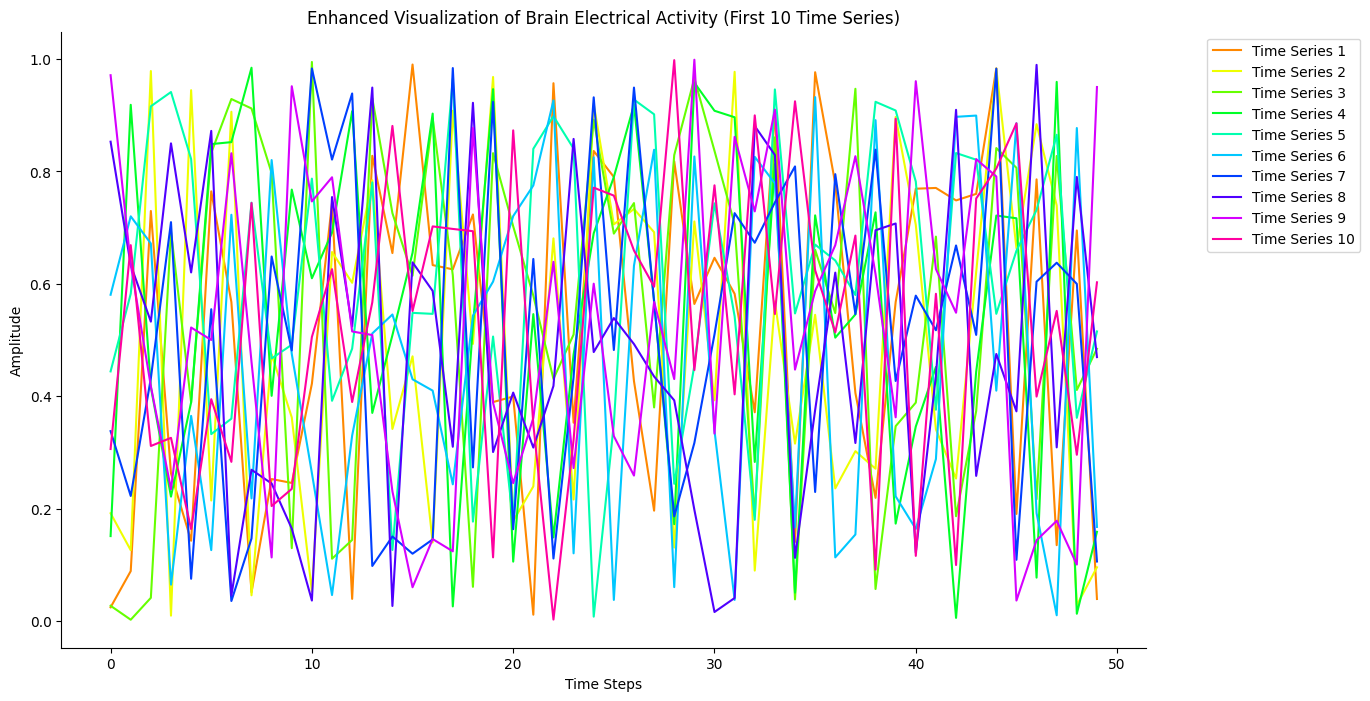

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming ts_task is your dataset loaded as a numpy array
# For demonstration, we'll create a random dataset
ts_task = np.random.rand(100, 2, 360, 176)

# Select the first person, first feeling, and first 10 time series for the first 50 time steps
person_idx = 0
feeling_idx = 0
time_series_indices = range(10)
time_steps = range(50)

plt.figure(figsize=(14, 8))
palette = sns.color_palette("hsv", len(time_series_indices))

for i, ts_idx in enumerate(time_series_indices):
    plt.plot(time_steps, ts_task[person_idx, feeling_idx, ts_idx, time_steps], label=f'Time Series {ts_idx + 1}', color=palette[i])
    
plt.title('Enhanced Visualization of Brain Electrical Activity (First 10 Time Series)')
plt.xlabel('Time Steps')
plt.ylabel('Amplitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.show()
